# Week 4: 手写 LoRA + SVD 可视化

**目标**: 从矩阵分解角度理解 LoRA,可视化低秩近似的质量。

**核心公式**:
```
W_new = W_0 + (alpha / rank) * B @ A
```

其中 B ∈ R^{d×r}, A ∈ R^{r×k}

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

## 1. SVD 分解可视化

看看预训练权重的奇异值衰减曲线

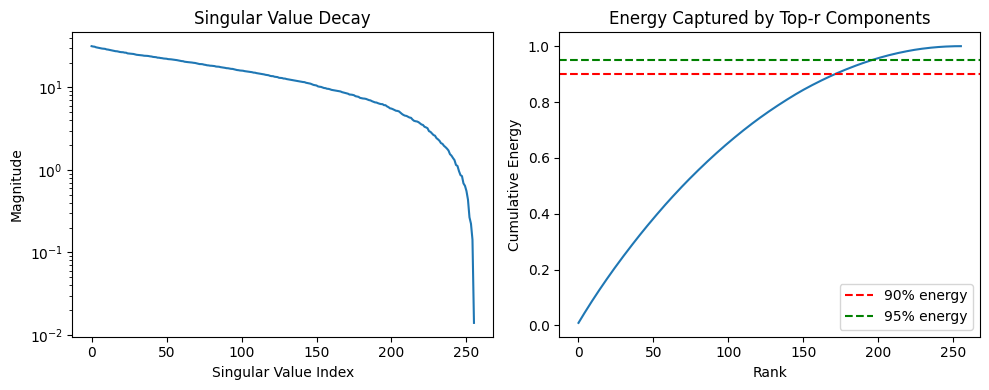

Rank   4: 3.57% energy
Rank   8: 7.01% energy
Rank  16: 13.56% energy
Rank  32: 25.54% energy
Rank  64: 46.26% energy


In [3]:
# 造一个模拟的预训练权重矩阵
torch.manual_seed(42)
d, k = 256, 256
W = torch.randn(d, k)

# SVD 分解 (注意: torch.linalg.svd 返回 Vh, 不是 V)
U, S, Vh = torch.linalg.svd(W)

# 画奇异值衰减曲线
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(S.numpy())
plt.xlabel("Singular Value Index")
plt.ylabel("Magnitude")
plt.title("Singular Value Decay")
plt.yscale("log")

# 画累计能量
cumulative = torch.cumsum(S, dim=0) / S.sum()
plt.subplot(1, 2, 2)
plt.plot(cumulative.numpy())
plt.axhline(y=0.9, color='r', linestyle='--', label='90% energy')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% energy')
plt.xlabel("Rank")
plt.ylabel("Cumulative Energy")
plt.title("Energy Captured by Top-r Components")
plt.legend()
plt.tight_layout()
plt.show()

# 看看前 r 个分量包含多少能量
for r in [4, 8, 16, 32, 64]:
    energy = cumulative[r-1].item()
    print(f"Rank {r:3d}: {energy:.2%} energy")

## 2. 低秩近似的质量

用不同 rank 近似 W,看重建误差

Rank   1: relative error = 0.9924
Rank   2: relative error = 0.9849
Rank   4: relative error = 0.9702
Rank   8: relative error = 0.9417
Rank  16: relative error = 0.8877
Rank  32: relative error = 0.7892
Rank  64: relative error = 0.6124
Rank 128: relative error = 0.3246


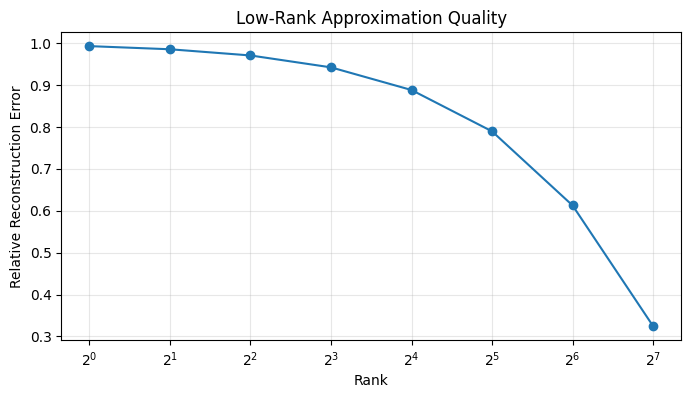

In [4]:
ranks = [1, 2, 4, 8, 16, 32, 64, 128]
errors = []

for r in ranks:
    # 取前 r 个分量重建 (torch.linalg.svd 返回 Vh, 重建用 Vh[:r,:])
    W_approx = U[:, :r] @ torch.diag(S[:r]) @ Vh[:r, :]
    error = torch.norm(W - W_approx, p='fro').item() / torch.norm(W, p='fro').item()
    errors.append(error)
    print(f"Rank {r:3d}: relative error = {error:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(ranks, errors, 'o-')
plt.xlabel("Rank")
plt.ylabel("Relative Reconstruction Error")
plt.title("Low-Rank Approximation Quality")
plt.xscale("log", base=2)
plt.grid(alpha=0.3)
plt.show()

## 3. LoRA 矩阵的可视化

看看 A 和 B 矩阵的结构

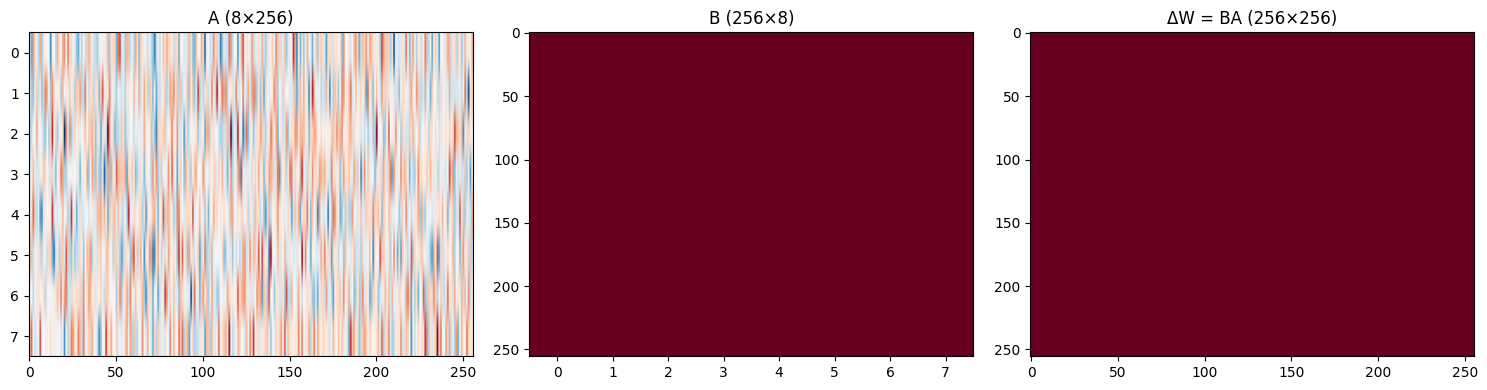

ΔW rank = 0


In [6]:
rank = 8
A = torch.randn(rank, k) * 0.01   # 小随机值
B = torch.zeros(d, rank)          # 0 初始化

delta_W = B @ A

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(A.numpy(), cmap='RdBu', aspect='auto')
axes[0].set_title(f"A ({rank}×{k})")
axes[1].imshow(B.numpy(), cmap='RdBu', aspect='auto')
axes[1].set_title(f"B ({d}×{rank})")
axes[2].imshow(delta_W.numpy(), cmap='RdBu', aspect='auto')
axes[2].set_title(f"ΔW = BA ({d}×{k})")
plt.tight_layout()
plt.show()

print(f"ΔW rank = {torch.linalg.matrix_rank(delta_W)}")

## 4. 手写 LoRALinear (和 lora_from_scratch.py 联动)

运行 `lora_from_scratch.py` 中的 LoRALinear 实现

In [7]:
# 从 lora_from_scratch.py 导入实现
from lora_from_scratch import LoRALinear, inject_lora

# 测试: 一个简单线性层的 LoRA 适配
linear = nn.Linear(64, 64)
x = torch.randn(2, 10, 64)

# 原始输出
y_original = linear(x)

# 用 LoRALinear 包装
lora_linear = LoRALinear(linear, rank=8, alpha=16)
y_lora = lora_linear(x)

# 验证初始时 y_lora ≈ y_original (因为 B=0)
diff = (y_lora - y_original).abs().max()
print(f"初始差异: {diff:.2e} (应该接近 0)")
print(f"LoRA 矩阵 A shape: {lora_linear.lora_A.shape}")
print(f"LoRA 矩阵 B shape: {lora_linear.lora_B.shape}")
print(f"B 的最大值: {lora_linear.lora_B.abs().max().item():.2e} (应该为 0)")


初始差异: 0.00e+00 (应该接近 0)
LoRA 矩阵 A shape: torch.Size([8, 64])
LoRA 矩阵 B shape: torch.Size([64, 8])
B 的最大值: 0.00e+00 (应该为 0)


---

**交付物**:
- 奇异值衰减曲线截图
- 低秩近似误差曲线
- `lora_from_scratch.py` 完整实现